In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- Sandbox Activation ---
def soft_sign_mod(x, shift=0.5):
    shifted_input = x - shift
    return shifted_input / (1 + torch.abs(shifted_input))

In [ ]:
class MiniNet(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.layer1 = nn.Linear(1, 16)
        self.layer2 = nn.Linear(16, 1)
        self.activation = activation

    def forward(self, x):
        x = self.activation(self.layer1(x))
        return self.layer2(x)

    
act_options = {
    "soft_sign_mod": soft_sign_mod,
    "softsign": F.softsign,
    "tanh": torch.tanh,
    "relu": F.relu,
}

model = MiniNet(activation=act_options["soft_sign_mod"])


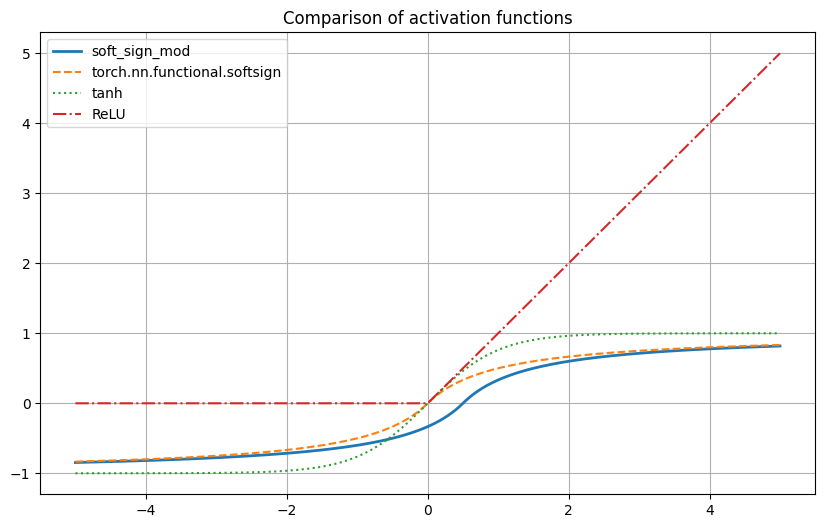

In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

def soft_sign_mod(x):
    shift = 0.5
    shifted_input = x - shift
    return shifted_input / (1 + torch.abs(shifted_input))

x = torch.linspace(-5, 5, 1000)

plt.figure(figsize=(10,6))
plt.plot(x, soft_sign_mod(x), label="soft_sign_mod", linewidth=2)
plt.plot(x, F.softsign(x), label="torch.nn.functional.softsign", linestyle="--")
plt.plot(x, torch.tanh(x), label="tanh", linestyle=":")
plt.plot(x, F.relu(x), label="ReLU", linestyle="-.")
plt.legend()
plt.title("Comparison of activation functions")
plt.grid(True)
plt.show()
